In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import rcParams
from pathlib import Path
import numpy as np

# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

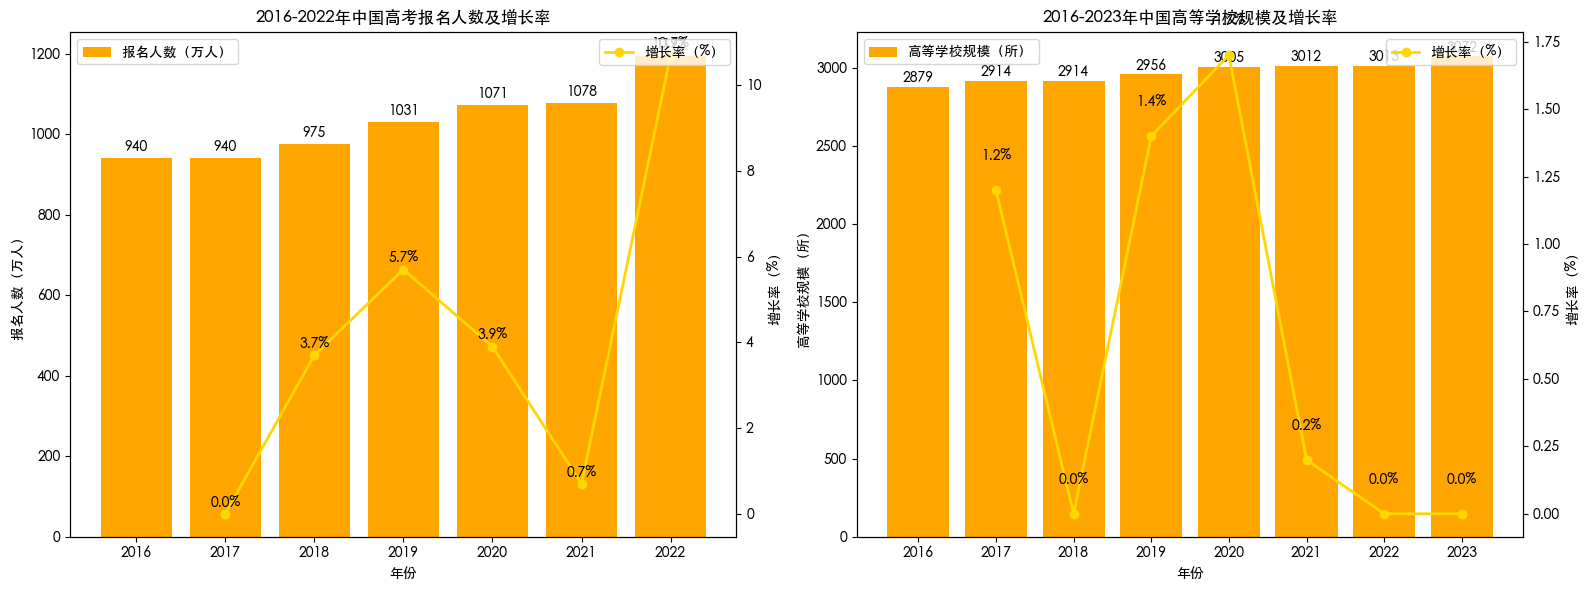

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# --------------------- 高考报名人数及增长率图表数据 ---------------------
years_gaokao = ["2016", "2017", "2018", "2019", "2020", "2021", "2022"]
enroll_gaokao = [940, 940, 975, 1031, 1071, 1078, 1193]
growth_gaokao = [np.nan, 0.0, 3.7, 5.7, 3.9, 0.7, 10.7]  # 2016年无增长率（作为起始年）

# --------------------- 高等学校规模及增长率图表数据 ---------------------
years_school = ["2016", "2017", "2018", "2019", "2020", "2021", "2022", "2023"]
scale_school = [2879, 2914, 2914, 2956, 3005, 3012, 3013, 3072]
growth_school = [np.nan, 1.2, 0.0, 1.4, 1.7, 0.2, 0.0, 0.0]  # 2016年无增长率（作为起始年）

# 创建画布，一行两列布局
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --------------------- 绘制高考报名人数及增长率图表（左图） ---------------------
ax1.bar(years_gaokao, enroll_gaokao, color='orange', label='报名人数（万人）')
ax1.set_ylabel('报名人数（万人）')
ax1.set_xlabel('年份')
ax1.set_title('2016-2022年中国高考报名人数及增长率')
ax1.legend(loc='upper left')

# 绘制增长率折线图（双轴）
ax1_2 = ax1.twinx()
ax1_2.plot(years_gaokao, growth_gaokao, marker='o', color='gold', label='增长率（%）', linewidth=2)
ax1_2.set_ylabel('增长率（%）')
ax1_2.legend(loc='upper right')

# 添加高考报名人数数值标注
for i, num in enumerate(enroll_gaokao):
    ax1.text(i, num + 10, f'{num}', ha='center', va='bottom')

# 添加高考增长率数值标注（2016年无，从2017开始）
for i, rate in enumerate(growth_gaokao[1:], start=1):
    ax1_2.text(i, rate + 0.1, f'{rate}%', ha='center', va='bottom')

# --------------------- 绘制高等学校规模及增长率图表（右图） ---------------------
ax2.bar(years_school, scale_school, color='orange', label='高等学校规模（所）')
ax2.set_ylabel('高等学校规模（所）')
ax2.set_xlabel('年份')
ax2.set_title('2016-2023年中国高等学校规模及增长率')
ax2.legend(loc='upper left')

# 绘制增长率折线图（双轴）
ax2_2 = ax2.twinx()
ax2_2.plot(years_school, growth_school, marker='o', color='gold', label='增长率（%）', linewidth=2)
ax2_2.set_ylabel('增长率（%）')
ax2_2.legend(loc='upper right')

# 添加高等学校规模数值标注
for i, num in enumerate(scale_school):
    ax2.text(i, num + 10, f'{num}', ha='center', va='bottom')

# 添加高等学校增长率数值标注（2016年无，从2017开始）
for i, rate in enumerate(growth_school[1:], start=1):
    ax2_2.text(i, rate + 0.1, f'{rate}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

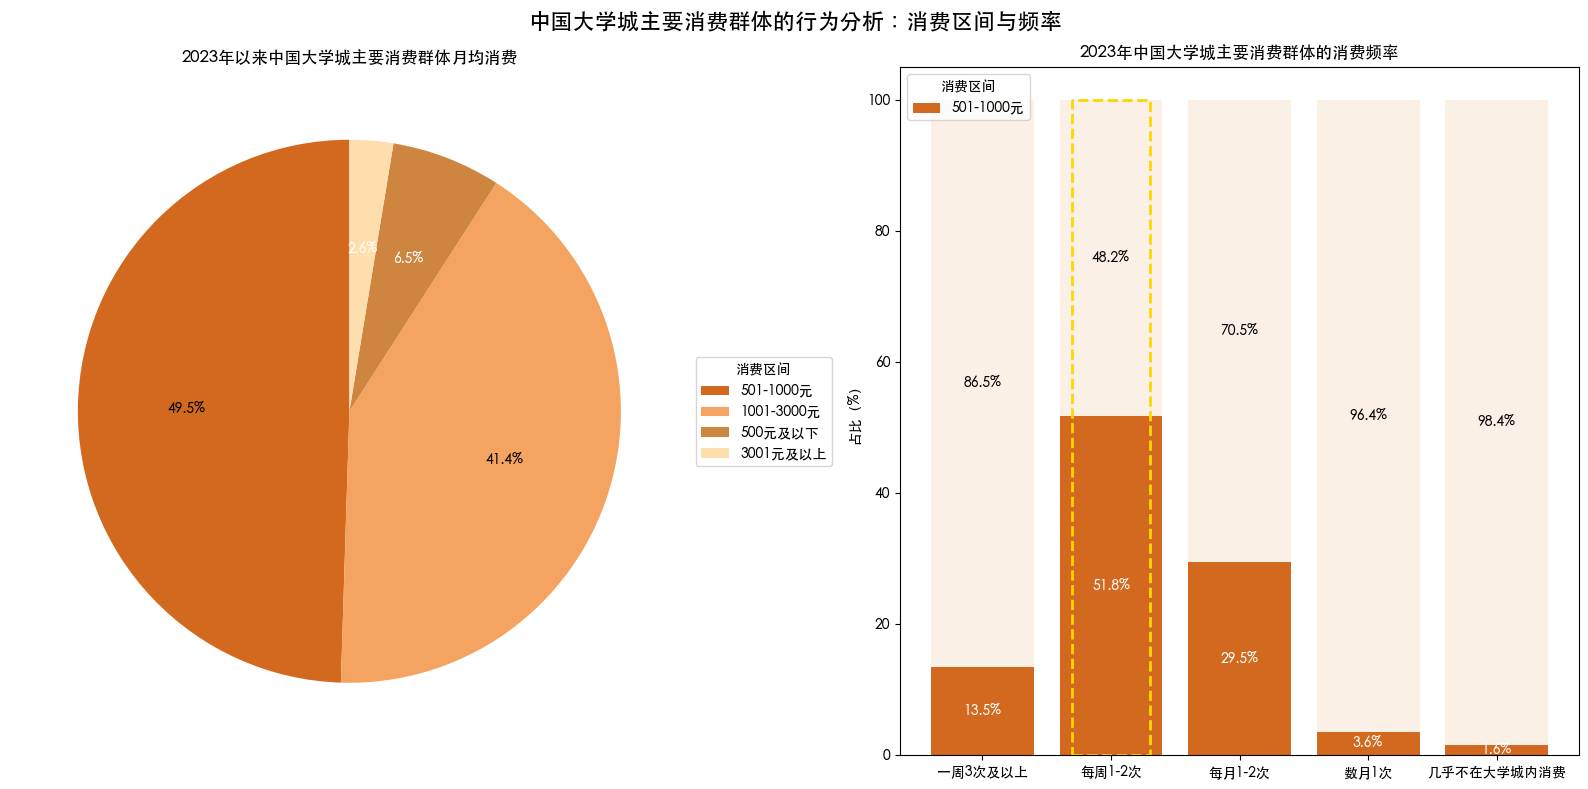

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# --------------------- 左侧饼图数据 ---------------------
labels_pie = ["501-1000元", "1001-3000元", "500元及以下", "3001元及以上"]
sizes_pie = [49.5, 41.4, 6.5, 2.6]
colors_pie = ["#D2691E", "#F4A460", "#CD853F", "#FFDEAD"]

# --------------------- 右侧分组柱状图数据 ---------------------
labels_bar = ["一周3次及以上", "每周1-2次", "每月1-2次", "数月1次", "几乎不在大学城内消费"]
sizes_bar = [
    [13.5, 86.5],  # 第一组：下方橙色、上方浅色
    [51.8, 48.2], 
    [29.5, 70.5], 
    [3.6, 96.4], 
    [1.6, 98.4]
]
colors_bar = ["#D2691E", "#FAF0E6"]  # 橙色、浅米色

# 创建画布，一行两列布局
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# --------------------- 绘制左侧饼图 ---------------------
wedges, texts, autotexts = ax1.pie(sizes_pie, colors=colors_pie, autopct='%1.1f%%', startangle=90)
ax1.set_title('2023年以来中国大学城主要消费群体月均消费')
# 调整图例
ax1.legend(wedges, labels_pie, title="消费区间", loc="center left", bbox_to_anchor=(1, 0.5))
# 调整标注文字颜色
for autotext in autotexts:
    autotext.set_color('white' if autotext.get_position()[1] > 0.5 else 'black')

# --------------------- 绘制右侧分组柱状图 ---------------------
# 分组柱状图绘制（堆叠形式）
x = np.arange(len(labels_bar))
bottom = np.zeros(len(labels_bar))
for i in range(2):
    ax2.bar(x, [size[i] for size in sizes_bar], bottom=bottom, color=colors_bar[i], label=labels_pie[i] if i==0 else '')
    bottom += [size[i] for size in sizes_bar]

ax2.set_title('2023年中国大学城主要消费群体的消费频率')
ax2.set_ylabel('占比（%）')
ax2.set_xticks(x)
ax2.set_xticklabels(labels_bar)
ax2.legend(title="消费区间", loc="upper left")

# 添加分组柱状图数值标注
for i, (size1, size2) in enumerate(sizes_bar):
    ax2.text(i, size1/2, f'{size1}%', ha='center', va='center', color='white')
    ax2.text(i, size1 + size2/2, f'{size2}%', ha='center', va='center', color='black')

# 模拟黄色虚线框（第二组）
ax2.plot([x[1]-0.3, x[1]+0.3, x[1]+0.3, x[1]-0.3, x[1]-0.3], 
         [0, 0, 100, 100, 0], 
         linestyle='--', color='gold', linewidth=2)

plt.suptitle('中国大学城主要消费群体的行为分析：消费区间与频率', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

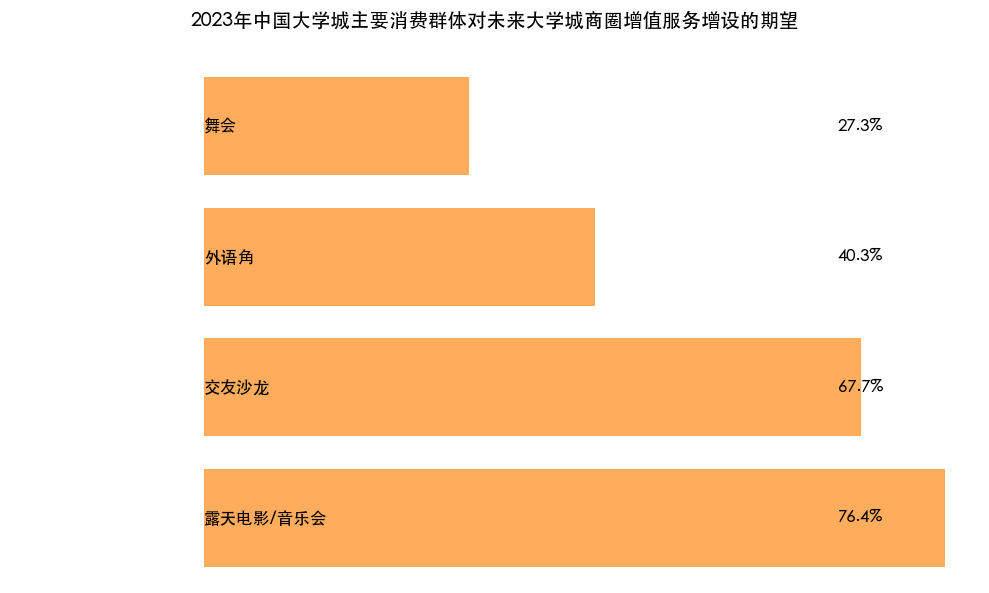

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# 数据准备
labels = ["露天电影/音乐会", "交友沙龙", "外语角", "舞会"]
percentages = [76.4, 67.7, 40.3, 27.3]
# 用文字模拟图标（可自定义更贴近的符号）
icons = ["露天电影/音乐会", "交友沙龙", "外语角", "舞会"]

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(0, 100)
ax.set_ylim(0, len(labels) * 2)
ax.set_axis_off()

for i, (label, perc, icon) in enumerate(zip(labels, percentages, icons)):
    # 绘制图标（文字形式）
    # ax.text(10, i * 2 + 1, icon, fontsize=20, va="center")
    # 绘制标签
    ax.text(20, i * 2 + 1, label, fontsize=12, va="center")
    # 绘制百分比
    ax.text(90, i * 2 + 1, f"{perc}%", fontsize=12, va="center", ha="right")
    # 绘制进度条
    ax.barh(i * 2 + 1, perc, left=20, height=1.5, color="#FF9933", alpha=0.8)

ax.set_title("2023年中国大学城主要消费群体对未来大学城商圈增值服务增设的期望", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()